Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Graph settings
plt.style.use('ggplot')

 Load Dataset

In [ ]:
df = pd.read_csv("Cleaned_Superstore.csv")
df.head()

,Ship_Mode,Segment,Country,City,State,Postal_Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


Basic Information

In [ ]:
df.shape

(9994, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship_Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal_Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub_Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [ ]:
df.describe()

,Postal_Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df.isnull().sum()

,0
Ship_Mode,0
Segment,0
Country,0
City,0
State,0
Postal_Code,0
Region,0
Category,0
Sub_Category,0
Sales,0


Sales Analysis

In [ ]:
#Total Sales
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


In [ ]:
#Average Sales
average_sales = df["Sales"].mean()
print("Average Sales:", average_sales)

Average Sales: 229.85800083049833


In [ ]:
#Highest Sale
highest_sale = df["Sales"].max()
print("Highest Sale:", highest_sale)

Highest Sale: 22638.48


In [ ]:
#Lowest Sale
lowest_sale = df["Sales"].min()
print("Lowest Sale:", lowest_sale)

Lowest Sale: 0.444


Profit Analysis

In [ ]:
#Total Profit
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [ ]:
#Average Profit
average_profit = df["Profit"].mean()
print("Average Profit:", average_profit)

Average Profit: 28.65689630778467


In [ ]:
#Profit Margin
profit_margin = (df["Profit"].sum() / df["Sales"].sum()) * 100
print("Profit Margin:", round(profit_margin,2), "%")

Profit Margin: 12.47 %


Category Analysis

In [ ]:
# Profit percentage by Category
profit_percentage = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
)
profit_percentage["Profit_Percentage"] = (
    profit_percentage["Profit"] / profit_percentage["Sales"]
) * 100
print(profit_percentage)

                       Sales       Profit  Profit_Percentage
Category                                                    
Furniture        741999.7953   18451.2728           2.486695
Office Supplies  719047.0320  122490.8008          17.035158
Technology       836154.0330  145454.9481          17.395712


In [ ]:
#Quantity by Category
quantity_category = df.groupby("Category")["Quantity"].sum()
print(quantity_category)

Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64


Sub-Category Analysis

In [ ]:
#Sales by Sub-Category
df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Sub_Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


In [ ]:
#Profit by Sub-Category
df.groupby("Sub_Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Sub_Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [ ]:
# Profit Percentage by Sub-Category
profit_percentage = (
    df.groupby("Sub_Category")[["Sales", "Profit"]]
      .sum()
)

profit_percentage["Profit %"] = (
    profit_percentage["Profit"] / profit_percentage["Sales"]
) * 100

profit_percentage = profit_percentage.sort_values(
    by="Profit %",
    ascending=False
)

print(profit_percentage.round(2))

                  Sales    Profit  Profit %
Sub_Category                               
Labels         12486.31   5546.25     44.42
Paper          78479.21  34053.57     43.39
Envelopes      16476.40   6964.18     42.27
Copiers       149528.03  55617.82     37.20
Fasteners       3024.28    949.52     31.40
Accessories   167380.32  41936.64     25.05
Art            27118.79   6527.79     24.07
Appliances    107532.16  18138.01     16.87
Binders       203412.73  30221.76     14.86
Furnishings    91705.16  13059.14     14.24
Phones        330007.05  44515.73     13.49
Storage       223843.61  21278.83      9.51
Chairs        328449.10  26590.17      8.10
Machines      189238.63   3384.76      1.79
Supplies       46673.54  -1189.10     -2.55
Bookcases     114880.00  -3472.56     -3.02
Tables        206965.53 -17725.48     -8.56


In [ ]:
#Loss-making Sub-Categories
df.groupby("Sub_Category")["Profit"].sum().sort_values()

,Profit
Sub_Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


Region Analysis

In [ ]:
# Profit Percentage by Region
profit_percentage = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
)

profit_percentage["Profit %"] = (
    profit_percentage["Profit"] / profit_percentage["Sales"]
) * 100

profit_percentage = profit_percentage.sort_values(
    by="Profit %",
    ascending=False
)

print(profit_percentage.round(2))

             Sales     Profit  Profit %
Region                                 
West     725457.82  108418.45     14.94
East     678781.24   91522.78     13.48
South    391721.90   46749.43     11.93
Central  501239.89   39706.36      7.92


State Analysis

In [ ]:
#Top 10 States by Sales
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


In [ ]:
#Top 10 States by Profit
df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

,Profit
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


In [ ]:
#Bottom 10 States by Profit
df.groupby("State")["Profit"].sum().sort_values().head(10)

,Profit
State,
Texas,-25729.3563
Ohio,-16971.3766
Pennsylvania,-15559.9603
Illinois,-12607.8870
North Carolina,-7490.9122
Colorado,-6527.8579
Tennessee,-5341.6936
Arizona,-3427.9246
Florida,-3399.3017


Segment Analysis

In [ ]:
#Sales by Segment
df.groupby("Segment")["Sales"].sum()

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


In [ ]:
#Profit by Segment
df.groupby("Segment")["Profit"].sum()

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


Ship Mode Analysis

In [ ]:
#Sales by Ship Mode
df.groupby("Ship_Mode")["Sales"].sum()

,Sales
Ship_Mode,
First Class,3.514284e+05
Same Day,1.283631e+05
Second Class,4.591936e+05
Standard Class,1.358216e+06


In [ ]:
#Profit by Ship Mode
df.groupby("Ship_Mode")["Profit"].sum()

,Profit
Ship_Mode,
First Class,48969.8399
Same Day,15891.7589
Second Class,57446.6354
Standard Class,164088.7875


Discount Analysis

In [ ]:
#Average Discount
df["Discount"].mean()

np.float64(0.15620272163297977)

In [ ]:
#Discount vs Profit
df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [ ]:
#Discount vs Sales
df[["Discount","Sales"]].corr()

,Discount,Sales
Discount,1.00000,-0.02819
Sales,-0.02819,1.00000


Visualizations

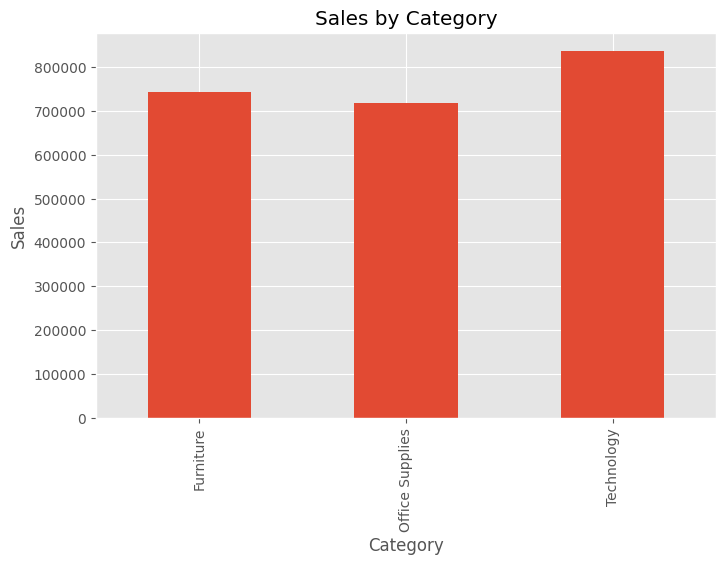

In [ ]:
#Sales by Category (Bar Chart)
sales_category = df.groupby("Category")["Sales"].sum()
sales_category.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.savefig("sales_by_category.png")
plt.show()

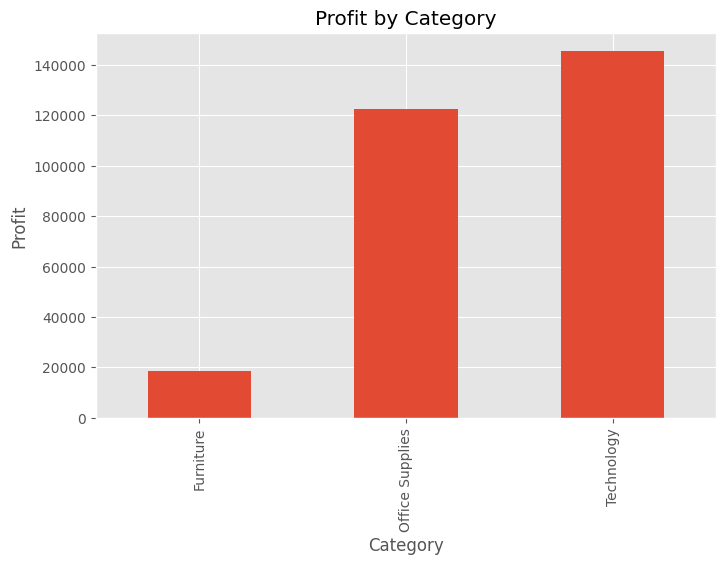

In [ ]:
#Profit by Category (Bar Chart)
profit_category = df.groupby("Category")["Profit"].sum()

profit_category.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.savefig("Images/profit_by_category.png")
plt.show()

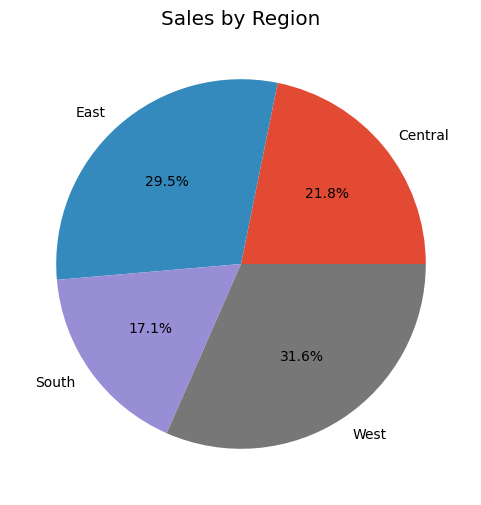

In [ ]:
#Sales by Region (Pie Chart)
sales_region = df.groupby("Region")["Sales"].sum()

sales_region.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sales by Region")
plt.ylabel("")
plt.savefig("Images/sales_region_pie.png")
plt.show()

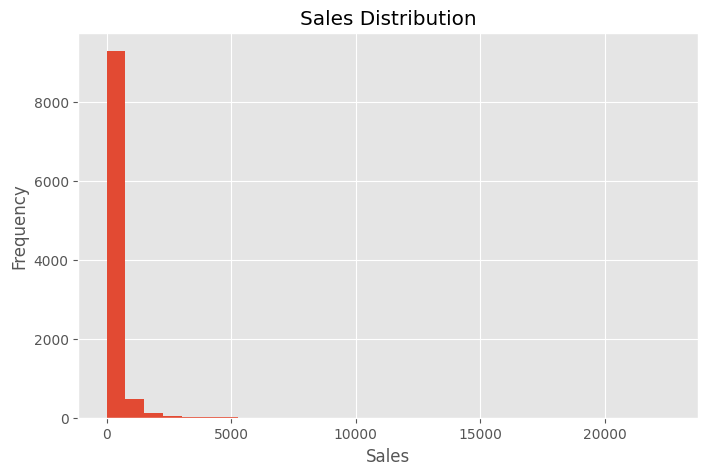

In [ ]:
#Sales Distribution (Histogram)
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.savefig("Images/sales_histogram.png")

plt.show()

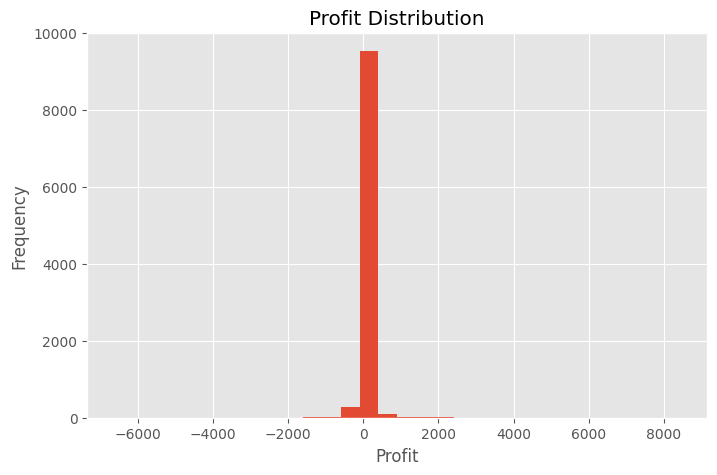

In [ ]:
#Profit Distribution (Histogram)
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.savefig("Images/profit_histogram.png")

plt.show()

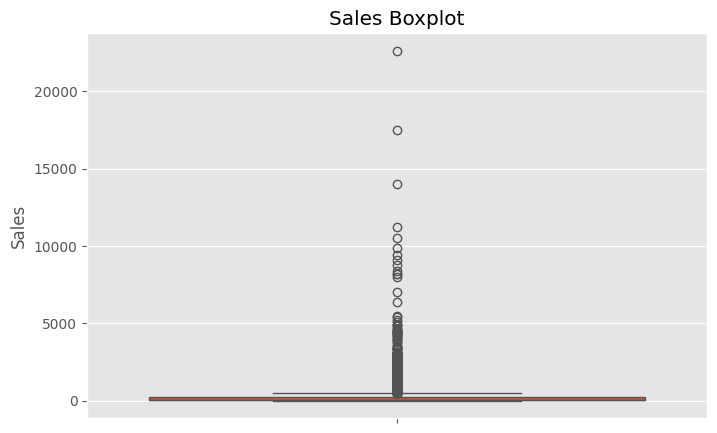

In [ ]:
#Sales Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Sales"])
plt.title("Sales Boxplot")
plt.savefig("Images/sales_boxplot.png")
plt.show()

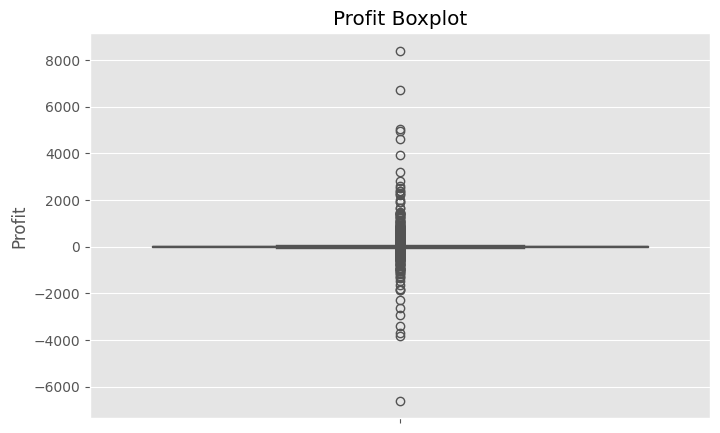

In [ ]:
#Profit Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Profit"])
plt.title("Profit Boxplot")
plt.savefig("Images/profit_boxplot.png")
plt.show()

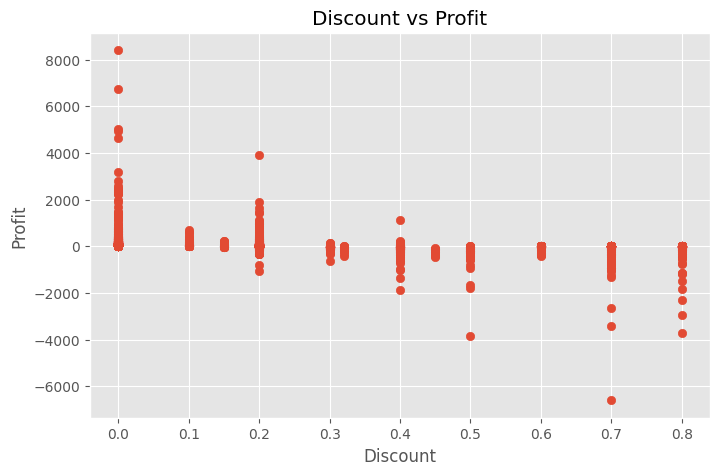

In [ ]:
#Discount vs Profit (Scatter Plot)
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.savefig("Images/discount_profit.png")
plt.show()

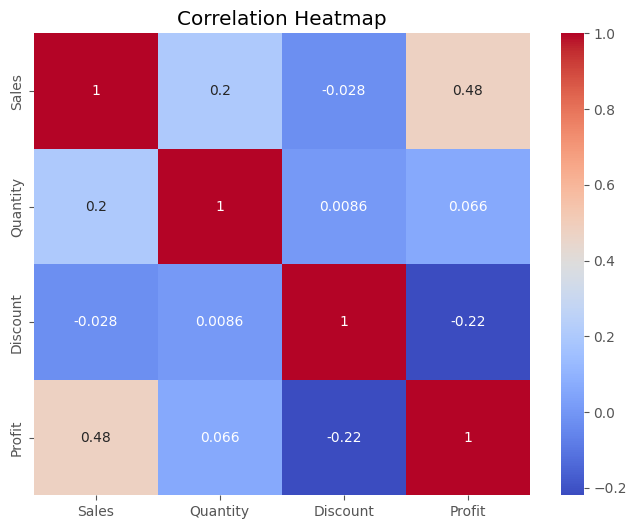

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales","Quantity","Discount","Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("Images/heatmap.png")

plt.show()

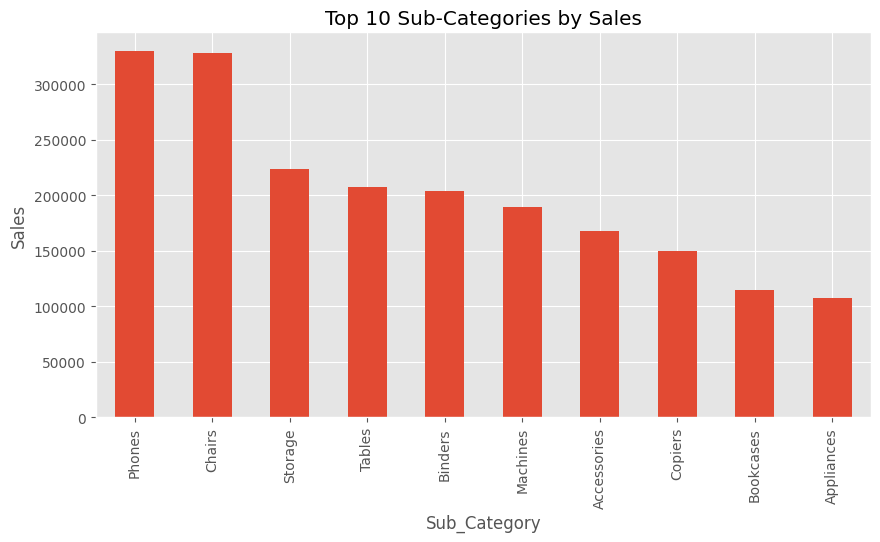

In [ ]:
#Pareto Chart (Top 10 Sub-Categories by Sales)
pareto = (
    df.groupby("Sub_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

pareto = pareto.head(10)
plt.figure(figsize=(10,5))
pareto.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub_Category")
plt.ylabel("Sales")

plt.savefig("Images/pareto_sales.png")
plt.show()